## Background
The aim of this document is to provide an easy click-and-create process to transform sequencing data, either provided by a external sequencing facility or your own lab's sequencer, into informative and interpretable microbiome data. The main disclaimer is that this document is specifically tailored for so-called 'paired-end' sequence data created with an Illumina machine (such as Illumina Novaseq, Miseq, Hiseq, or Nextseq models). The key data formats required to make use of this document are two fastq.gz files and a plain text file (See Chapter 1 for a more detailed description of the three files).<br>

The majority of the steps below will be performed using the open source software QIIME2 (Quantitative Insights Into Microbial Ecology version 2) (Bolyen et al., 2019 (doi: [10.1038/s41587-019-0209-9](https://www.nature.com/articles/s41587-019-0209-9)). QIIME2 is described and maintained at https://qiime2.org/ with helpful extensive explanations, tutorials and an active help forum, if you want to learn more. Current and previous releases can be found at (and installed from) [https://qiime2.org](https://qiime2.org/).<br>


# Chapter 1: Configuration

In Chapter 1 the focus is configuration of your Google Drive to enable to communicate with Google Colab to import input data and to store output data, figures and other results. During the use of the document, you will be asked information or consent necessary to communicate with your Google Drive, which is strictlyt required for successful progress further down the line.

Before you move on, make sure that you have the following files accessible on the computer you are working from right now:
* a .zip file containing only three files: 2 files with raw sequence data for forward and reverse sequences, and a metadata file. The former two should roughly resemble {your_filename}R1.fastq.gz and {your_filename}R2.fastq.gz, which correspond to forward sequence reads (R1) and the reverse sequence reads (R2) of the paired-end data. Note that all sequence data of all your sequenced samples need to be contained within these two files. If you have two files per sample, ask your sequencing company for 'multiplexed fastq.gz files instead of demultiplexed fastq.gz files'. The third file is a separated plain text file (e.g., {file_name}.mapping.tsv) containing the the sample identifiers and crucial sequencing related metadata information.
* Primers used (name and sequence)
Confirm to comply to each of the points listed:
* Enough storage in your google drive account (in total you need at least 3 times the size of the .zip file)
* Enough computing power (if you .zip file size is larger than 500MB, the free version of Google Colab is likely insufficient in terms of memory (RAM) and/or computing power (CPUs). We have successfully processed larger data sets using the Google Colab PRO version (~10 Euro/Month). We advise to take such a subscription if required.<br>


## Chapter 1.1: Install QIIME2

In the code block below, the software package manager *Conda* will be installed. After the installation of conda, QIIME2 version `Qiime2.2022.11` is installed into a virtual conda environment and other required software.
**It is vital not to change code blocks or any code within them** throughout this document. **Only proceed to run the next code block after the previous code block has been successfully finished (green checkmark visible.)** This first code block takes ~ 10 minutes to complete, while later code blocks could take up to a few hours to complete due to heavy computing, depending on the size of your data set. Patience is advised.

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()
!conda env create -n qiime2-2022.11 --file https://data.qiime2.org/distro/core/qiime2-2022.11-py38-linux-conda.yml
!conda install -n qiime2-2022.11 unzip conda-forge::biopython

Streaminguitvoer ingekort tot de laatste 5000 regels.





















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































## Chapter 1.2: Importing software

Start here with importing software and connecting your Google Drive with this document in Google Colab.

First, choose the Google account to use, login if asked, and provide consent for ALL permissions, otherwise the programs below cannot successfully execute nor save results.


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!rm -rf /content/wetsus_repo_analysis
!git clone https://github.com/jippeS/wetsus_repo_analysis.git
import sys
import os
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML, Image
import shutil
from google.colab import files
import importlib
if not '/content/wetsus_repo_analysis' in sys.path:
    sys.path.append('/content/wetsus_repo_analysis')
import scripts.package_workshop  as pw

importlib.reload(pw)

Mounted at /content/drive
Cloning into 'wetsus_repo_analysis'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 193 (delta 102), reused 129 (delta 45), pack-reused 0 (from 0)
Receiving objects: 100% (193/193), 2.51 MiB | 8.77 MiB/s, done.
Resolving deltas: 100% (102/102), done.


<module 'scripts.package_workshop' from '/content/wetsus_repo_analysis/scripts/package_workshop.py'>

## Chapter 1.3: Create a project

To start with a new project, choose "new_project" in the dropdown menu. This creates an input text bar where you are asked to name the main folder were all input and output will be stored. Run the next code block to create the folder.

In case you used this document before, you could choose previously used folders to work in. Note, if you want to choose to re-do an analysis, start again at Chapter 1.1 (and do not re-run the code block of Chapter 2.1).

In [2]:
dropdown_widget, text_box_widget = pw.create_main_folder(widgets, clear_output, display)

De map 'drive/MyDrive/H2Omics_data_analysis' bestaat al.


Dropdown(description='Folder:', options=('Choose', 'new_project', 'Project_1', 'Project_2', 'Project_3', 'Proj…

Output()

In [3]:
folder_path = pw.chosen_folder(dropdown_widget, text_box_widget)

De map 'drive/MyDrive/H2Omics_data_analysis/Project_5/qiime_analysis' is aangemaakt.


## Chapter 1.4: Upload

The input .zip file (see Introductory text) needs to be uploaded from your computer. The program will automatically place it in the correct folder. To upload a large .zip file (>500 MB), it can be more efficient to navigate to the folder path (see output previous code block) via the browser, and manually upload the .zip file into this directory. Uploading large data files through Google Colab tends to be (much) slower.

In [6]:
pw.upload_files(files, shutil, folder_path)

KeyboardInterrupt: 

## Chapter 1.5: File names and CPU power choices

In this code block you will specify the file names of your results. It is advised to include a Project ID, PCR primer names, and Date (Example: `Proj1_515FY_926R_20250620`). In case you are analyzing a large data set (>500 MB), upgrade to Google Colab PRO enabling access to 8 CPU cores, instead of 2 CPU cores in the free version. Runtime from this point onwards can exceed 7 hours. Upgrading speeds up runtime by hours.

Make sure to CHECK with the output below if it shows the correct number of cores. For a Google Colab PRO subscription it should print `CPU cores: 8`. If not, close and reopen this Colab document, re-run the code blocks above, and check the Number of CPU cores again.

In [4]:
input_box, cores, outputdir = pw.naming_convention(folder_path, widgets)

Text(value='', description='Name:', layout=Layout(width='50%'), placeholder='Enter a name for the output files…

Output()

Number of CPU cores: 2


In [5]:
name_convention, metadata, name_convention_PairEndSequences= pw.create_names(input_box)


_PairEndSequences.qza


## Chapter 1.6: Select the PCR primers used prior to sequencing

In the next blocks you need to select the primer set used in the PCR, prior to the amplicon sequencing. NOTE: By choosing the "New_primers" option, you are able to use a non-standard primers, which  you have to correctly supply yourself! Please use this option with caution. Standard primers are typically advised for microbiome analysis.

In [9]:
dic_primers = pw.create_first_dropdown_primers(widgets)

In [11]:
dic_primer_output = pw.primer_dropdown(dic_primers, display, clear_output)

Dropdown(description='Forward:', index=6, options=('Choose', 'new_primer', '27F', '8F', '341F', '515F', '515F-…

Output()

Dropdown(description='Reverse:', index=5, options=('Choose', 'new_primer', '1492R', '785R', '806R', '926R', '1…

Output()

In [12]:
forward_primer_seq, reverse_primer_seq = pw.finalize_primers(dic_primer_output)

Chosen forward primer: 515F-Y: GTGYCAGCMGCCGCGGTAA
Chosen reverse primer: 926R: CCGYCAATTYMTTTRAGTTT


#Chapter 2: Qiime analysis

In Chapter 2, you will start cleaning and processing the sequence data. The output will be .qza files (QIIME-zipped Artifacts) .qzv files (QIIME-zipped Visualizations). .qza files will be the key files generating figues later on in the workflow. .qzv files can be quickly viewed at [view.qiime2.org](https://view.qiime2.org). Note that additional quality control steps will follow later on, and we suggest to consider the .qzv results only for exploratory purposes.

## Chapter 2.1: Correcting read directions and directory structure

This pre-processing step will double check the raw input files and correct forward/reverse assignment that are typically wrongly assigned in a small fraction of Illumina sequences. Furthermore, the metadata file will be correctly formatted for further use, and a directory structure will be prepared to organizing intermediate and output files.

In [13]:
!source activate qiime2-2022.11 && bash /content/wetsus_repo_analysis/scripts/qiime_commands/step1.sh $folder_path $metadata $forward_primer_seq $reverse_primer_seq $name_convention_PairEndSequences $outputdir

['input']
Traceback (most recent call last):
  File "wetsus_repo_analysis/scripts/pre_data.py", line 114, in <module>
    sys.exit(main())
  File "wetsus_repo_analysis/scripts/pre_data.py", line 109, in main
    extracted_folder = pre_data.opening_files()
  File "wetsus_repo_analysis/scripts/pre_data.py", line 40, in opening_files
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
  File "/usr/local/envs/qiime2-2022.11/lib/python3.8/zipfile.py", line 1251, in __init__
    self.fp = io.open(file, filemode)
IsADirectoryError: [Errno 21] Is a directory: 'drive/MyDrive/H2Omics_data_analysis/Project_5/qiime_analysis/'
mv: cannot stat 'drive/MyDrive/H2Omics_data_analysis/Project_5/qiime_analysis/input/*.fastq': No such file or directory
mv: cannot stat 'drive/MyDrive/H2Omics_data_analysis/Project_5/qiime_analysis/input/*.txt': No such file or directory
Traceback (most recent call last):
  File "wetsus_repo_analysis/scripts/pre_demux.py", line 119, in <module>
    sys.exit(main())
  Fil

##Chapter 2.2: Checking metadata column names

This code block checks and renames variables and file names, if required.If you choose to re-run any code block below, first, you need to confirm that this block executes without errors.

In [14]:
metadata1, input_file, demux, untrimmed = pw.qiime_path_1(folder_path, metadata, name_convention_PairEndSequences, name_convention, outputdir)
error_rate, p_trim_left, p_trim_right, p_trunc_len_f, p_trunc_len_r = pw.qiime_arguments()
output_trimmed, representative, table, denoising_stats, output_repr_table, output_repr_table_name = pw.qiime_path_2(outputdir, name_convention)
mafft_output, masked_output, unrooted_tree_output, rooted_tree = pw.qiime_path_3(outputdir, name_convention)

## Chapter 2.3: Clean the data

In the following blocks we will clean the data by demultiplexing samples, trimming primers, sequencing error correction, identifying Amplicon Sequence Variants (ASVs), dereplicating ASVs, idenfitying and removing chimeric sequences.

### Chapter 2.3.1: Demultiplexing

Knowing that your sequence data is still in a multiplexed state (all samples still together in the raw data files), you first proceed with demultiplexing the paired-end reads, the process of separating sequence reads belonging to different samples. This process is performed internally, which means will not see sample-specific files as a result. The separated reads will remain contained within a single, but newly formed, demux.qza file.

In order to separate reads by sample, QIIME2 relies on a software plugin called cutadapt. To demultiplex, QIIME2's demultiplexing command qiime cutadapt demux-paired requires sample-specific identifiers: the barcode sequences. This barcode should be part of the metadata plain text file. This should be part of the metadata mapping file, made available by the sequencing facility, and uploaded in the initial .zip file.

In [ ]:
!source activate qiime2-2022.11 && qiime cutadapt demux-paired --m-forward-barcodes-column BarcodeSequence --m-forward-barcodes-file $metadata1 --i-seqs $input_file --p-error-rate $error_rate --o-per-sample-sequences $demux --o-untrimmed-sequences $untrimmed --p-cores $cores

Saved SampleData[PairedEndSequencesWithQuality] to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_demux.qza
Saved MultiplexedPairedEndBarcodeInSequence to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_untrimmed.qza


### Chapter 2.3.2: Trimming data

Before continuing with inferring amplicon sequence variants, these primer sequences need to be removed.
Trimming primers can be perfomed using the function qiime cutadapt trim-paired to create a file called trimmed-demux-seqs.qza.
You can find the primer sequences specified in metadata.txt.

In [ ]:
!source activate qiime2-2022.11 && qiime cutadapt trim-paired --i-demultiplexed-sequences $demux --p-front-f $forward_primer_seq --p-front-r $reverse_primer_seq --p-discard-untrimmed --o-trimmed-sequences $output_trimmed --p-cores $cores

Saved SampleData[PairedEndSequencesWithQuality] to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_trimmed_demux_seqs.qza


### Background Section: what are amplicon sequence variants, why using them instead of OTUs, and how to deal with sequencing errors?

Sequencing errors are an intrinsic issue of sequencing data. Disentangling biological variation from sequencing error is critical for robust and accurate sequencing experiments. Amplicon sequence data are commonly used to describe the composition of microbial communities in biological samples. However, if not aptly dealt with, sequencing errors in your amplicon sequences likely cause false positive (and false negative) taxon assignments. As such, sequence errors lead to artificially inflated patterns of diversity in your sample, compared with the true biological diversity in the ecosystem the sample was collected from. To reduce false-positive bias as a result of sequence errors, sequences that vary by < 3% sequence similarity were traditionally clustered into operational taxonomic units (OTUs). Yet, this approach suffers from discarding true biological variation, which leads to false negative bias. In addition to discarding biological information with clustering sequences into OTUs, OTU assignments are completely dataset-dependent. OTUs can thus never be directly compared among studies, nor reproduced within a study.

In response to the improving quality of Illumina sequencing data, other methodologies have been developed for using sequence quality information to estimate and correct sequencing errors with so-called 'error correction models'. The exact corrected sequences (essentially 'OTUs with 100% similarity') are called Amplicon Sequence Variants (ASVs). ASVs provide improved resolution and accuracy. Leveraging all biological variation in the sequence data, ASVs are also fully reproducible, and can be compared directly among studies. The DADA2 algorithim is one of the best performing and widely used methods for sequence error correction. You can read more about ASVs, DADA2 and the benefits of error-correction methods over OTUs in the following articles: Callahan et al., 2016 (doi: [10.1038/nmeth.3869](https://www.nature.com/articles/nmeth.3869)), Callahan et al. 2017 (doi: [10.1038/ismej.2017.119](https://www.nature.com/articles/ismej2017119)). DADA2 and comparable methods (e.g., Deblur; Amir et al. 2017 (doi: [10.1128/mSystems.00191-16](https://msystems.asm.org/content/2/2/e00191-16))) can be run as integrated plugins of QIIME2.


###Chapter 2.3.3: Denoising the data
The DADA2 algorithm trains an error-correction model on (part of) the input sequence data and then uses the predicted errors to **(1) correct erroneously called bases**. The subsequent steps included in the `qiime dada2 denoise-paired` command automatically **(2) merges the corrected forward and reverse reads** into a longer single fragment of the 16S rRNA gene. It further identifies and **(3) removes chimeric sequences** (i.e. hybrid sequence artifacts of PCR). In the final step of the DADA2 workflow, the merged **(4) sequences are dereplicated**. Dereplication reduces the data volume greatly by counting the abundance of each unique sequence (ASV), and saves one copy of the ASV sequence (`representative_sequences.qza`) and its associated abundance as a sequence read count. Combining this information of all ASVs and all samples results in an ASV-by-sample matrix (`table.qza`), traditionally referred to as 'OTU table'. Additional statistics on the DADA2 denoising process are stored (`denoising_stats.qza`), which provide an overview of the number of sequences lost at each step of the process. (relatively long runtime)

In [ ]:
!source activate qiime2-2022.11 && qiime dada2 denoise-paired --i-demultiplexed-seqs $output_trimmed --p-trim-left-f $p_trim_left --p-trim-left-r $p_trim_right --p-trunc-len-f $p_trunc_len_f --p-trunc-len-r $p_trunc_len_r --o-table  $table --o-representative-sequences $representative --o-denoising-stats $denoising_stats --p-n-threads $cores

Saved FeatureTable[Frequency] to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_table.qza
Saved FeatureData[Sequence] to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_representative_sequences.qza
Saved SampleData[DADA2Stats] to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_denoising_stats.qza


### Chapter 2.4: Export representative sequences to .fasta format

The ASV representative sequences are exported to .fasta format for later use to predict 16S rRNA copy numbers per taxon.

In [ ]:
!source activate qiime2-2022.11 && qiime tools export --input-path $representative --output-path $outputdir/
!mv $output_repr_table $output_repr_table_name

Exported drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_representative_sequences.qza as DNASequencesDirectoryFormat to directory drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/




### Chapter 2.5: Alignment of representative sequences to create a maximum-likelihood phylogenetic tree

The next step in the workflow is to create a phylogeny (i.e. a phylogenetic tree) based on the sequence similarity among the ASV's representative sequences. This process requires first to create an alignment of all the representative sequences using a multiple sequence alignment tool, such as the `MAFFT` plugin (Katoh and Standley, 2013 (doi: [10.1093/molbev/mst010](https://academic.oup.com/mbe/article/30/4/772/1073398))). (relatively long runtime)

In [ ]:
!source activate qiime2-2022.11 && qiime alignment mafft --i-sequences $representative --o-alignment $mafft_output --p-n-threads $cores

Saved FeatureData[AlignedSequence] to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_aligned-rep-seqs.qza


When this code block completed successfully, the ASV representative sequences have been aligned. Then, uninformative parts of the sequences ('gaps') should be masked from the alignment:

In [ ]:
!source activate qiime2-2022.11 && qiime alignment mask --i-alignment $mafft_output --o-masked-alignment $masked_output

Saved FeatureData[AlignedSequence] to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_masked_aligned-rep-seqs.qza


The alignment has been filtered for gaps as well. Now you can continue with building a phylogeny based on the masked alignment using the q2-phylogeny plugin of your choice (e.g. FastTree2, IQ-Tree, RAxML). This workflow uses FastTree2 (Price et al., 2010 (doi: 10.1371/journal.pone.0009490)).

In [ ]:
!source activate qiime2-2022.11 && qiime phylogeny fasttree --i-alignment $masked_output --o-tree $unrooted_tree_output --p-n-threads $cores

Saved Phylogeny[Unrooted] to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_unrooted-tree.qza


The tree now needs to be rooted. Root the tree by placing the root at the midpoint of the longest tip-to-tip distance in the unrooted tree.

In [ ]:
!source activate qiime2-2022.11 && qiime phylogeny midpoint-root --i-tree $unrooted_tree_output --o-rooted-tree $rooted_tree

Saved Phylogeny[Rooted] to: drive/MyDrive/H2Omics_data_analysis/SYAN/qiime_analysis/output/test_syan_rooted-tree.qza


#Chapter 3: Taxonomy assignment

Taxonomic classification of sequence reads using QIIME2 is based on a feature classifier.
A machine learning model 'naive Bayesian' classifier is trained on a reference database to later assign taxonomy to your sequences.
The SILVA database with full 16S rRNA gene sequences of Bacteria and Archaea with associated taxonomic information is used.
The trained SILVA classifier will be downloaded in Chapter 3.1.

**DO NOT CLOSE THIS WINDOW DURING THE FOLLOWING!**<br>
To be able to use and assign the taxanomy for free (requires much computational power), you will need to briefly switch to another website called a Galaxy server: [Galaxy_EU_website](https://usegalaxy.eu/?tool_id=toolshed.g2.bx.psu.edu%2Frepos%2Fq2d2%2Fqiime2__feature_classifier__classify_sklearn%2Fqiime2__feature_classifier__classify_sklearn%2F2025.4.0%2Bq2galaxy.2025.4.0&version=latest)

## Chapter 3.1: Download files

To generate the taxonomy assignment, first the correct (pre-trained) classifier needs to be downloaded, and uploaded to the Galaxy platform.

Download the Classifier by pressing this link:
[download_link](https://data.qiime2.org/2022.11/common/silva-138-99-nb-classifier.qza)

Then, your ASV representative sequences need to be downloaded from your Google Drive:

In [ ]:
#Galaxy classifier
files.download(representative)

Change the version the website makes use of to 2022.11. For the classifier model to work, you need to align your used QIIME2 version with the QIIME2 version on the Galaxy Server. NOTE: otherwise the classifier you downloaded will not work on your representative sequences. Follow the screenshots below, guiding you through the process on the Galaxy Server to generate a taxonomic classification.

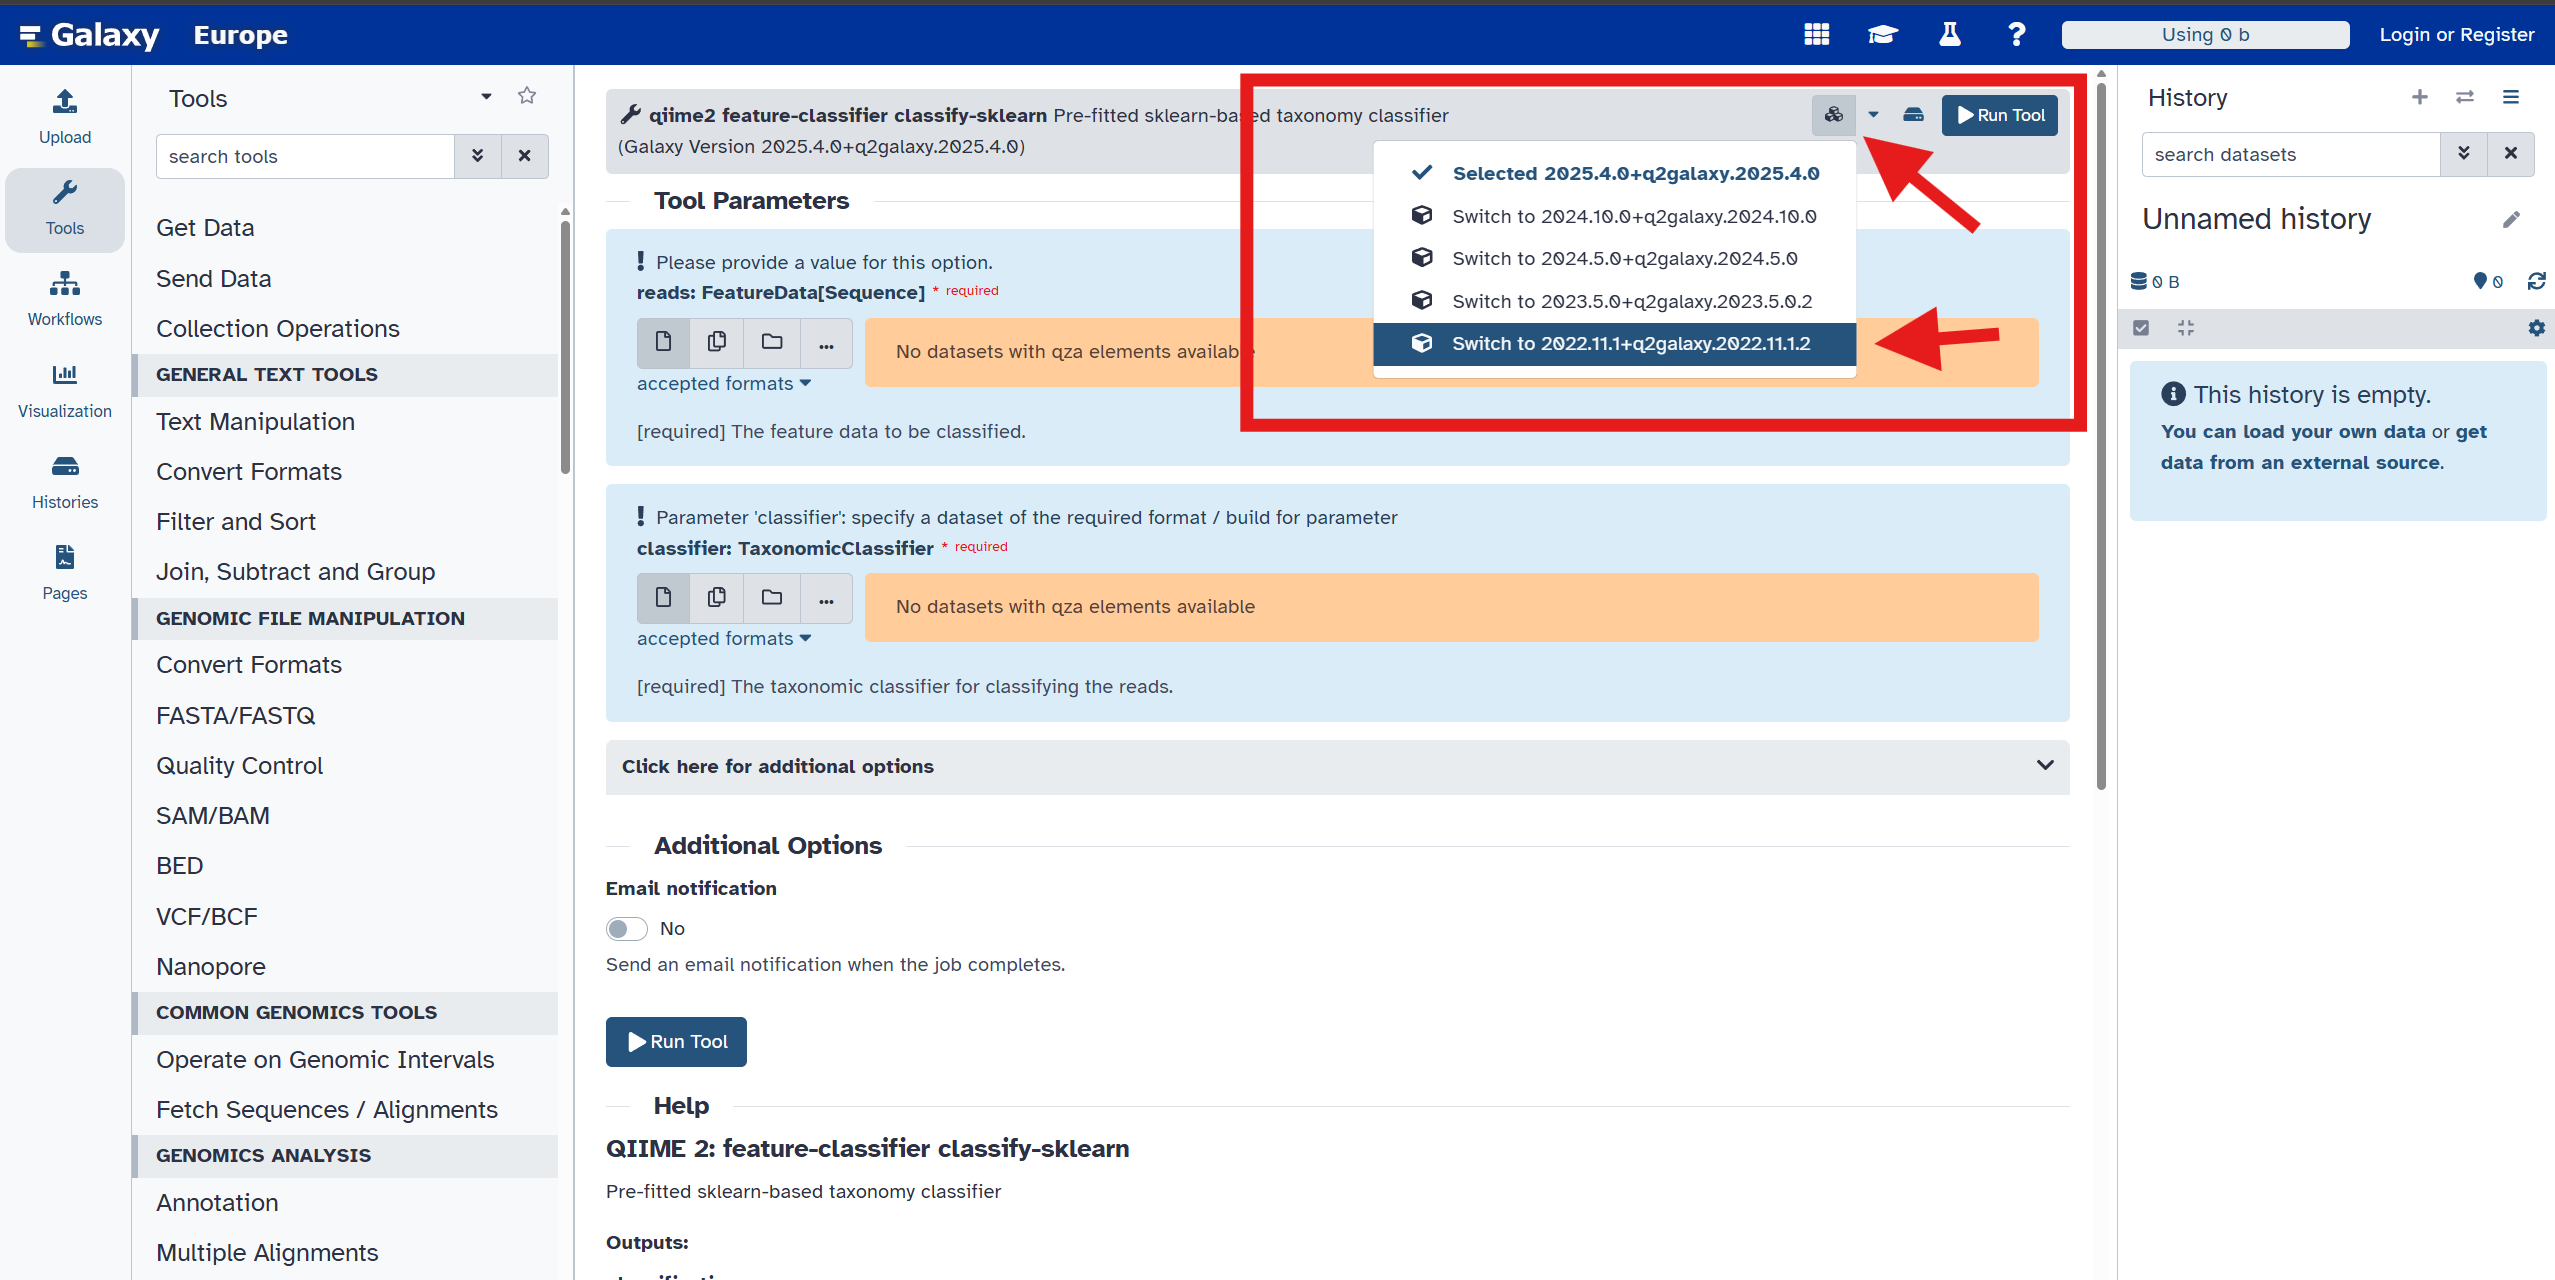

In [ ]:
from IPython.display import display, Image
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step1.png'))

You have not uploaded anything to the Galaxy Server yet. So, next, press the three dots `...` as pinpointed below.

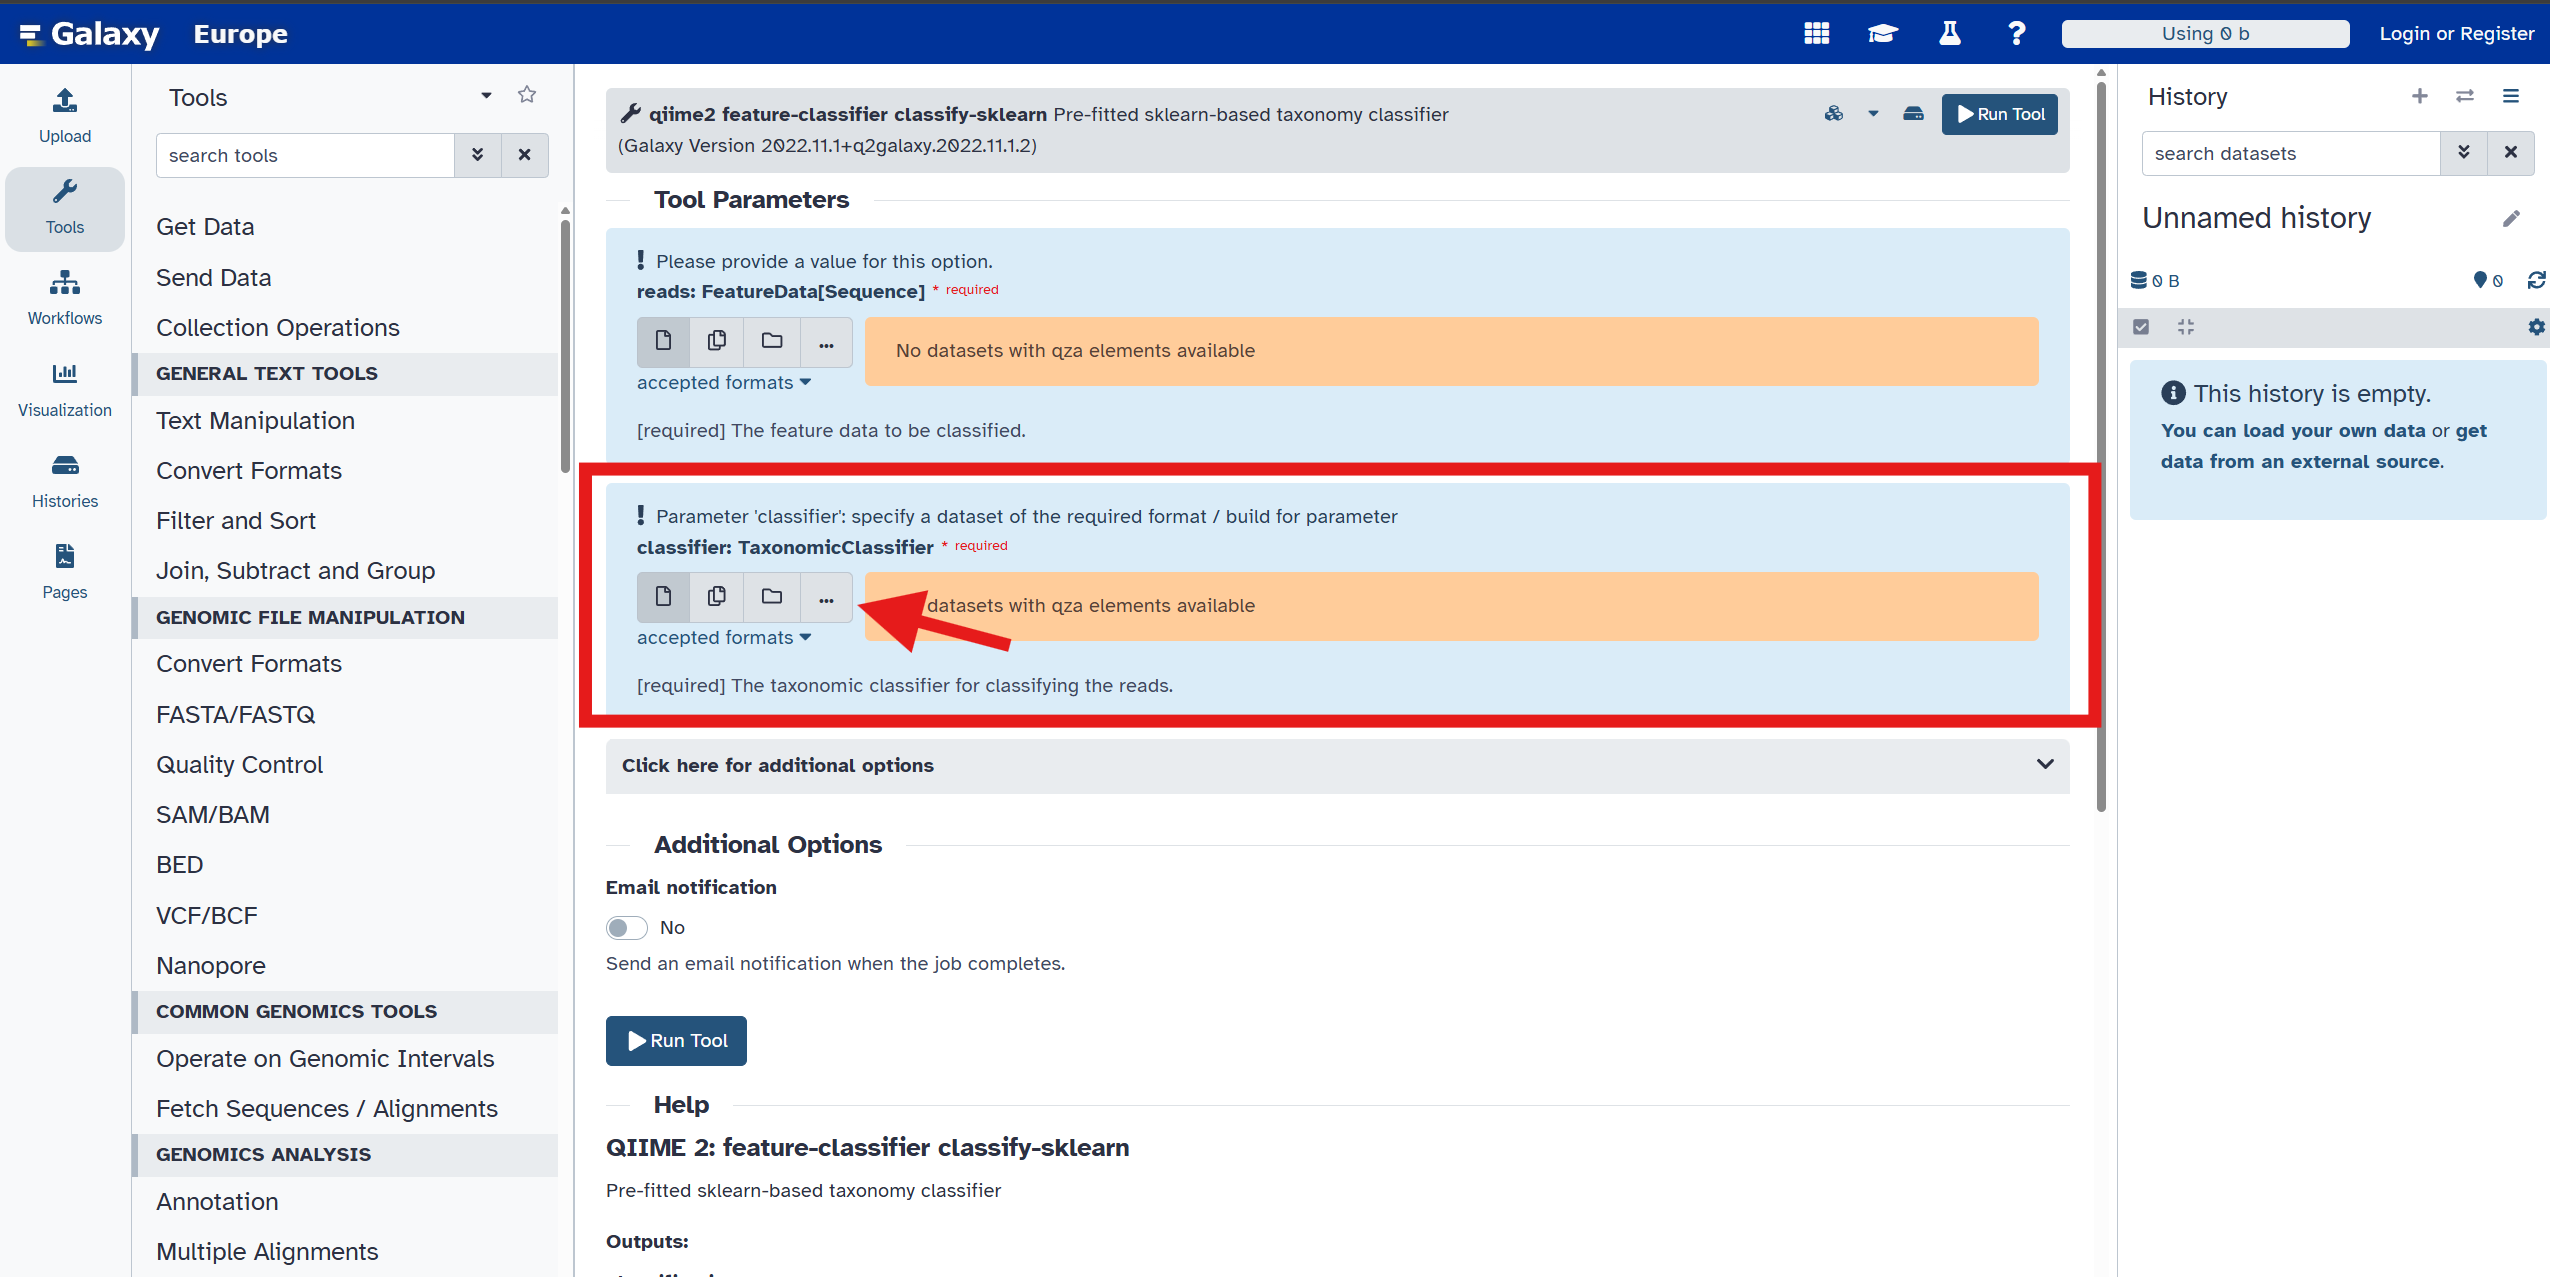

In [ ]:
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step2.png'))

At "classifier:TaxonomicClassifier", press the button "Choose local file" and select SILVA classifier that you downloaded through the link in chapter 3.1.

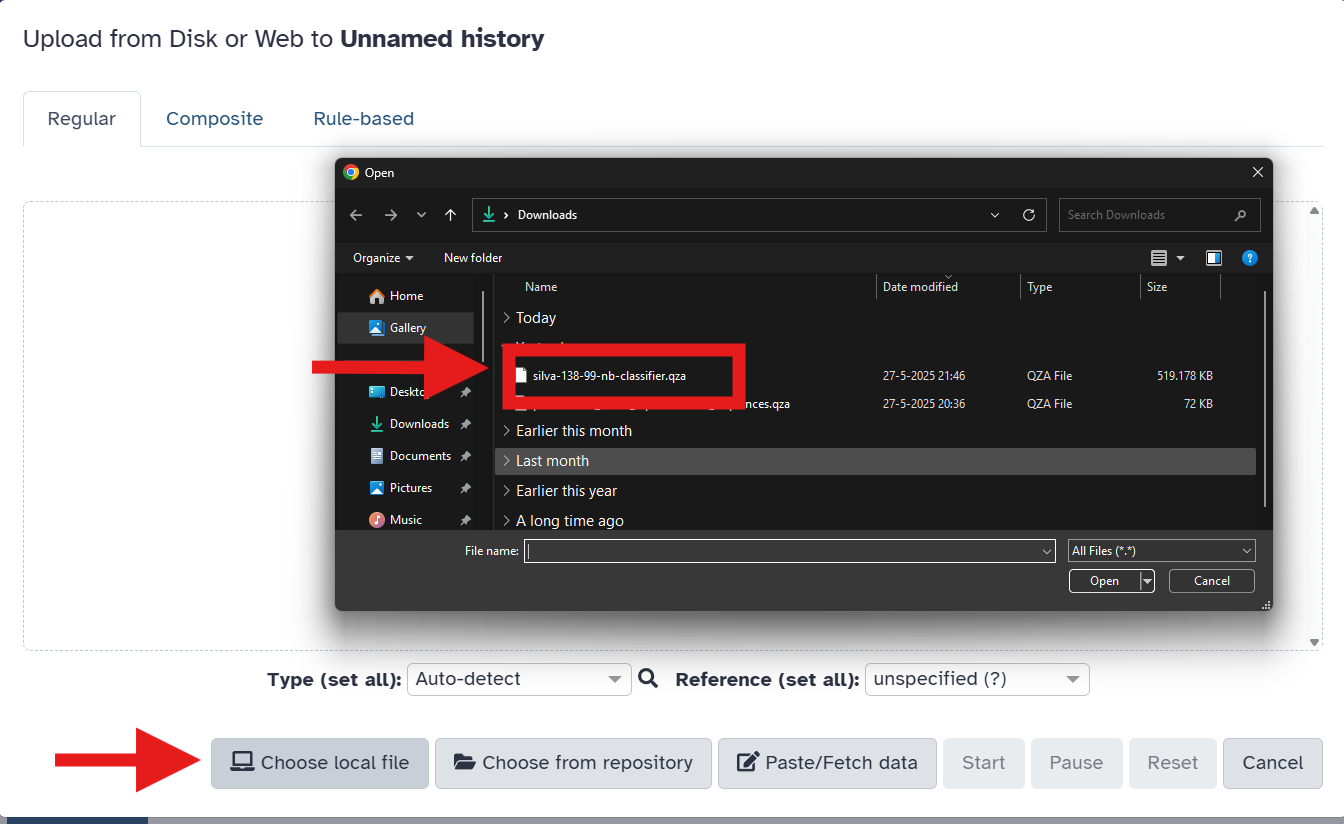

In [ ]:
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step3.png'))

Press "Start" to upload the data.

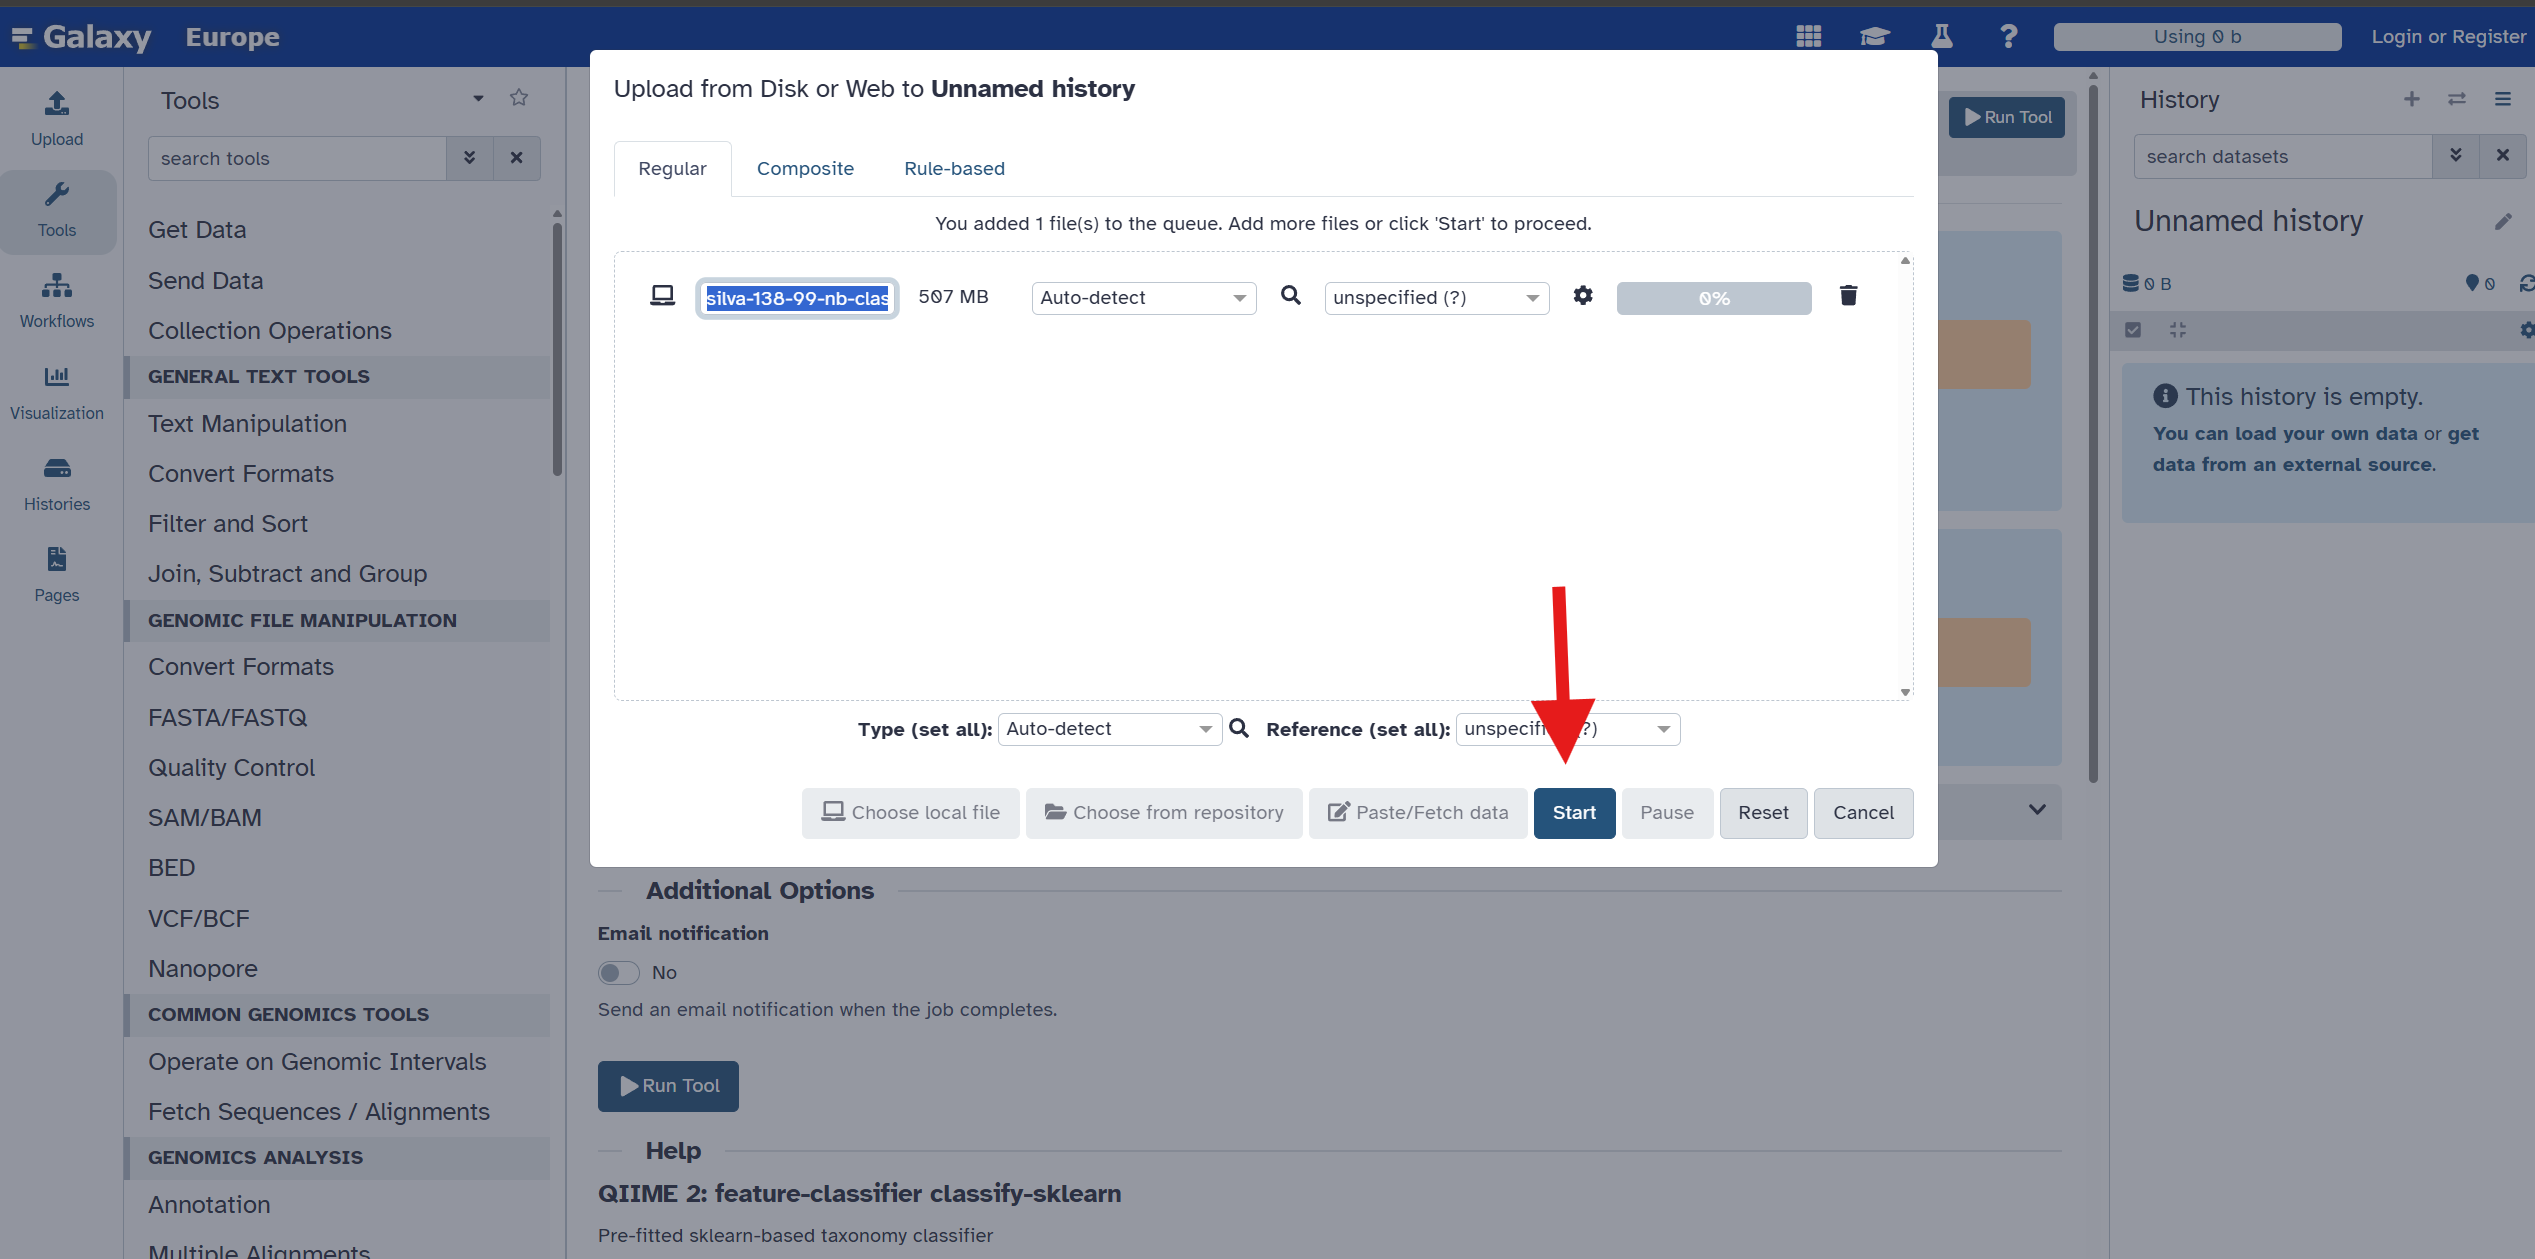

In [ ]:
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step4.png'))

A successful upload will show in the righthand panel as a green box with the classifier name showing that it has been uploaded.

Now similarly upload the representative.qza for the "FeatureData[Sequence]" input:

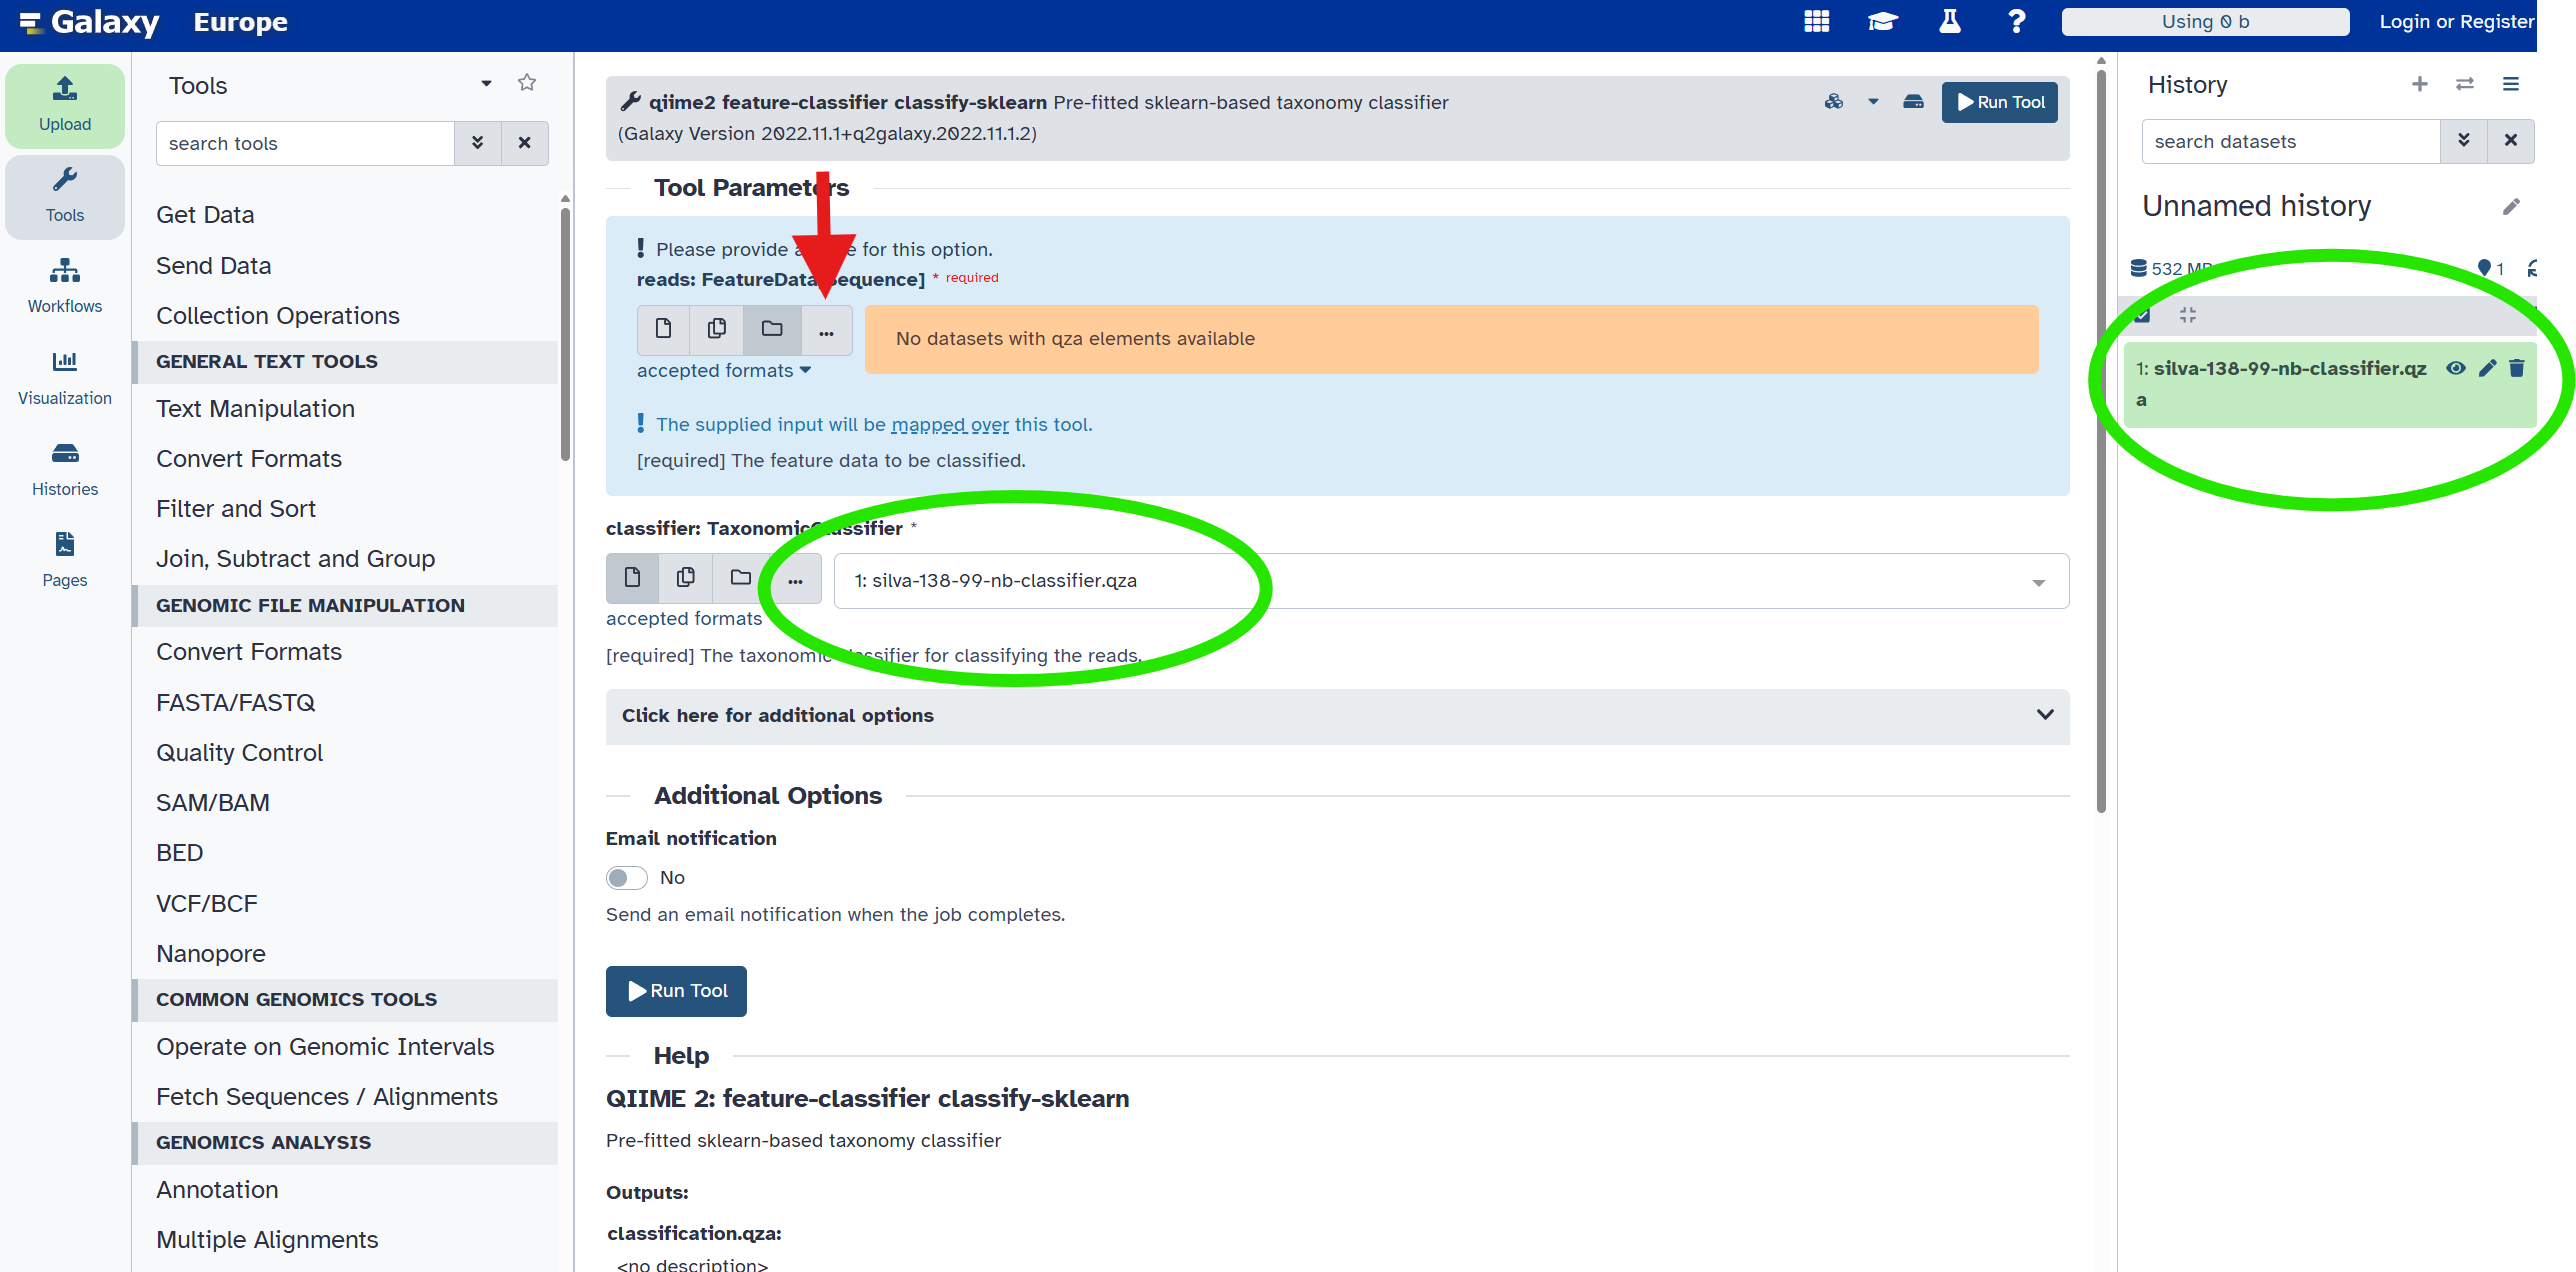

In [ ]:
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step5.png'))

You might see the uploaded classifier when you try to upload the representative sequences. Navigate to the representative sequences to upload.

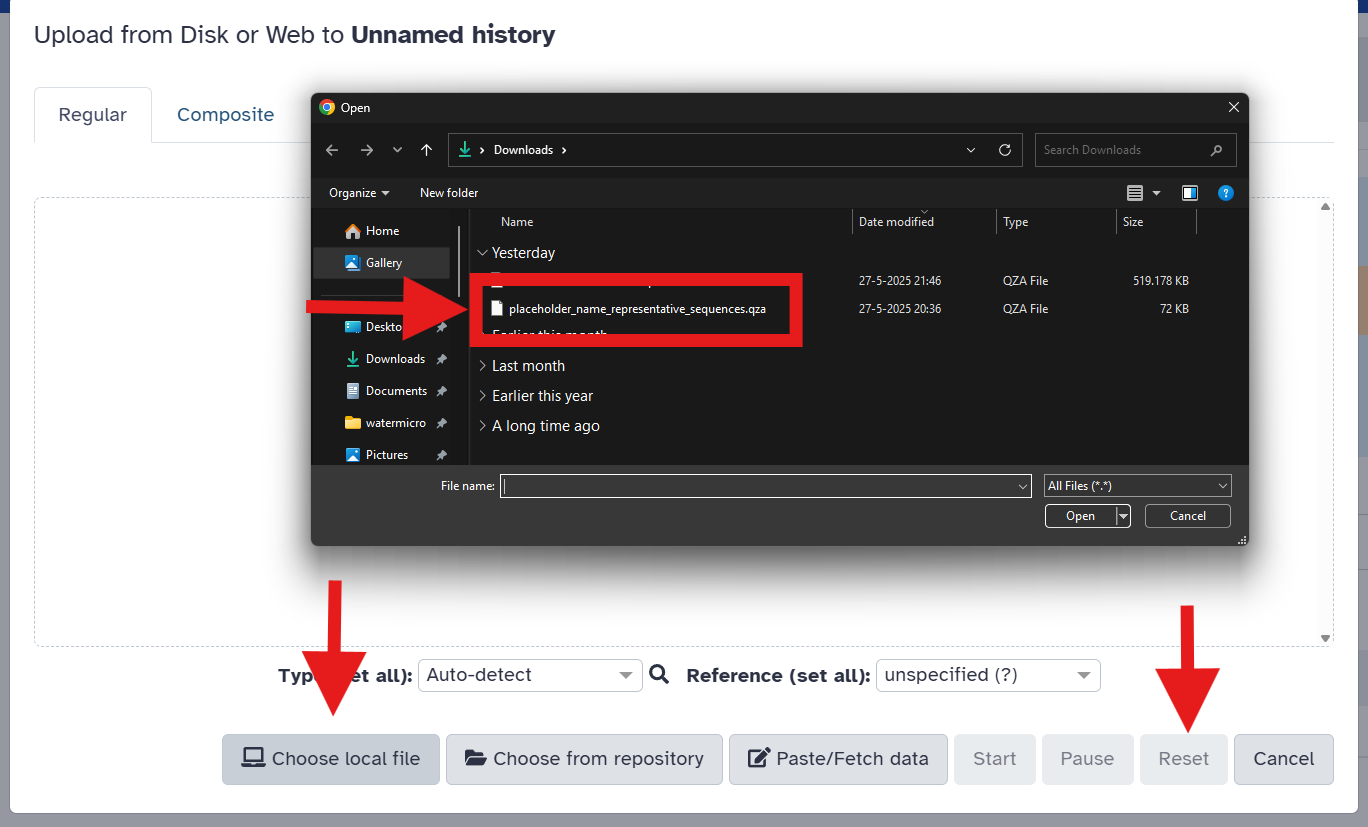

In [ ]:
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step6.png'))

You might have to go to this screen and go back to the three dots for the FeatureData[Sequence] data to select the uploaded representative_sequences.qza. After you can press the "Run tool" and wait until the orange box on the right turns green.

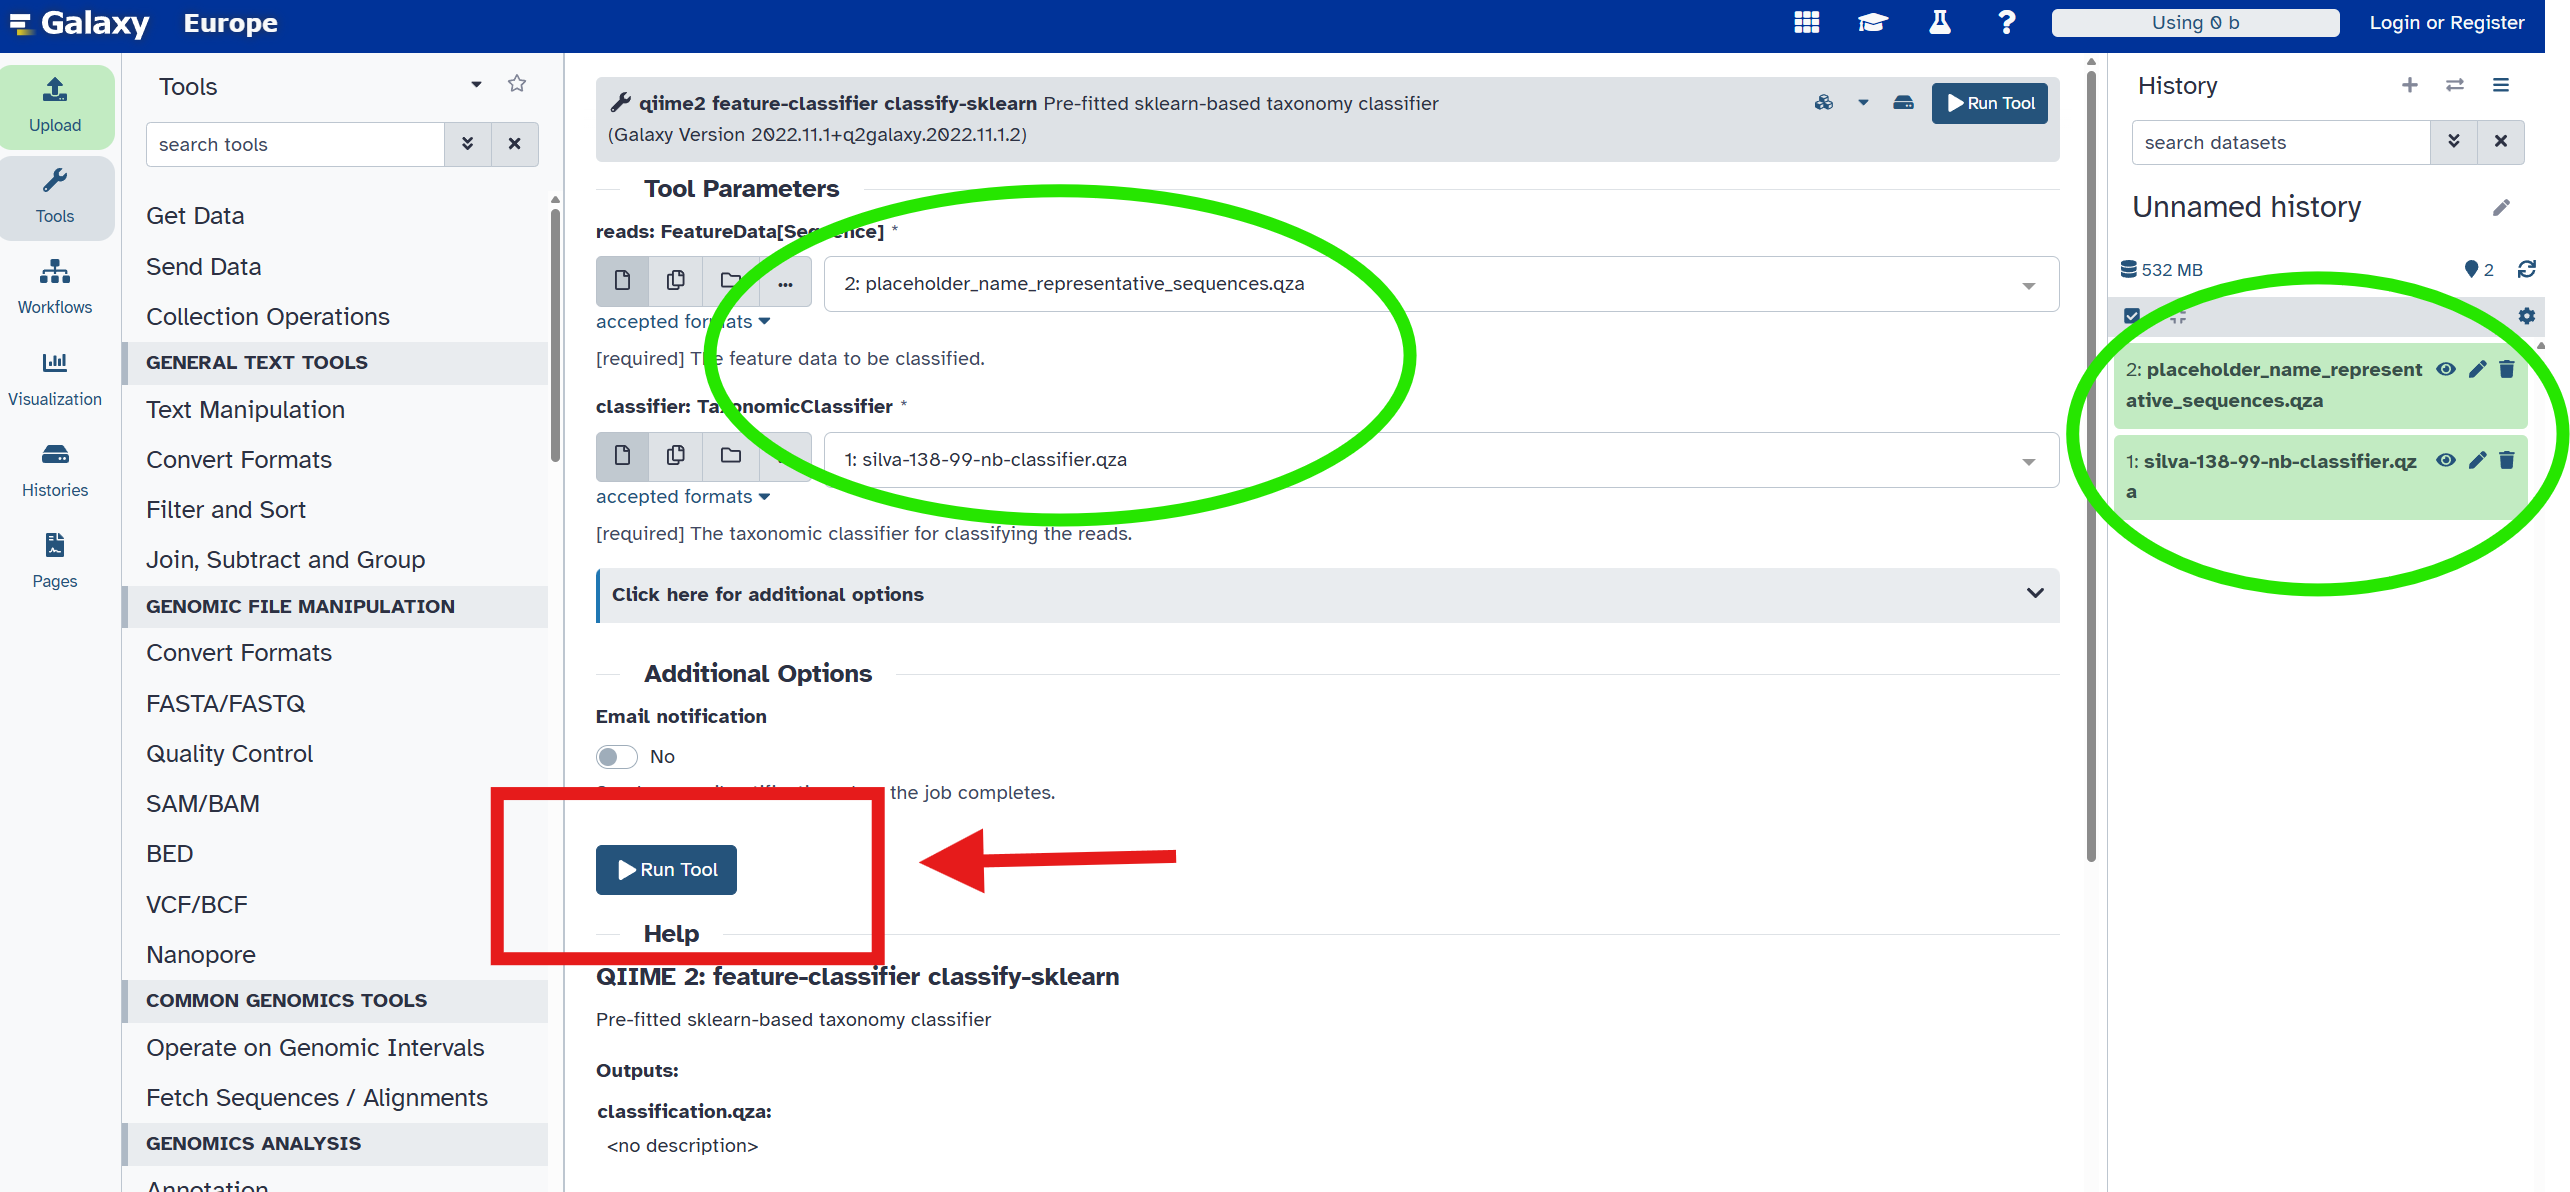

In [ ]:
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step7.png'))

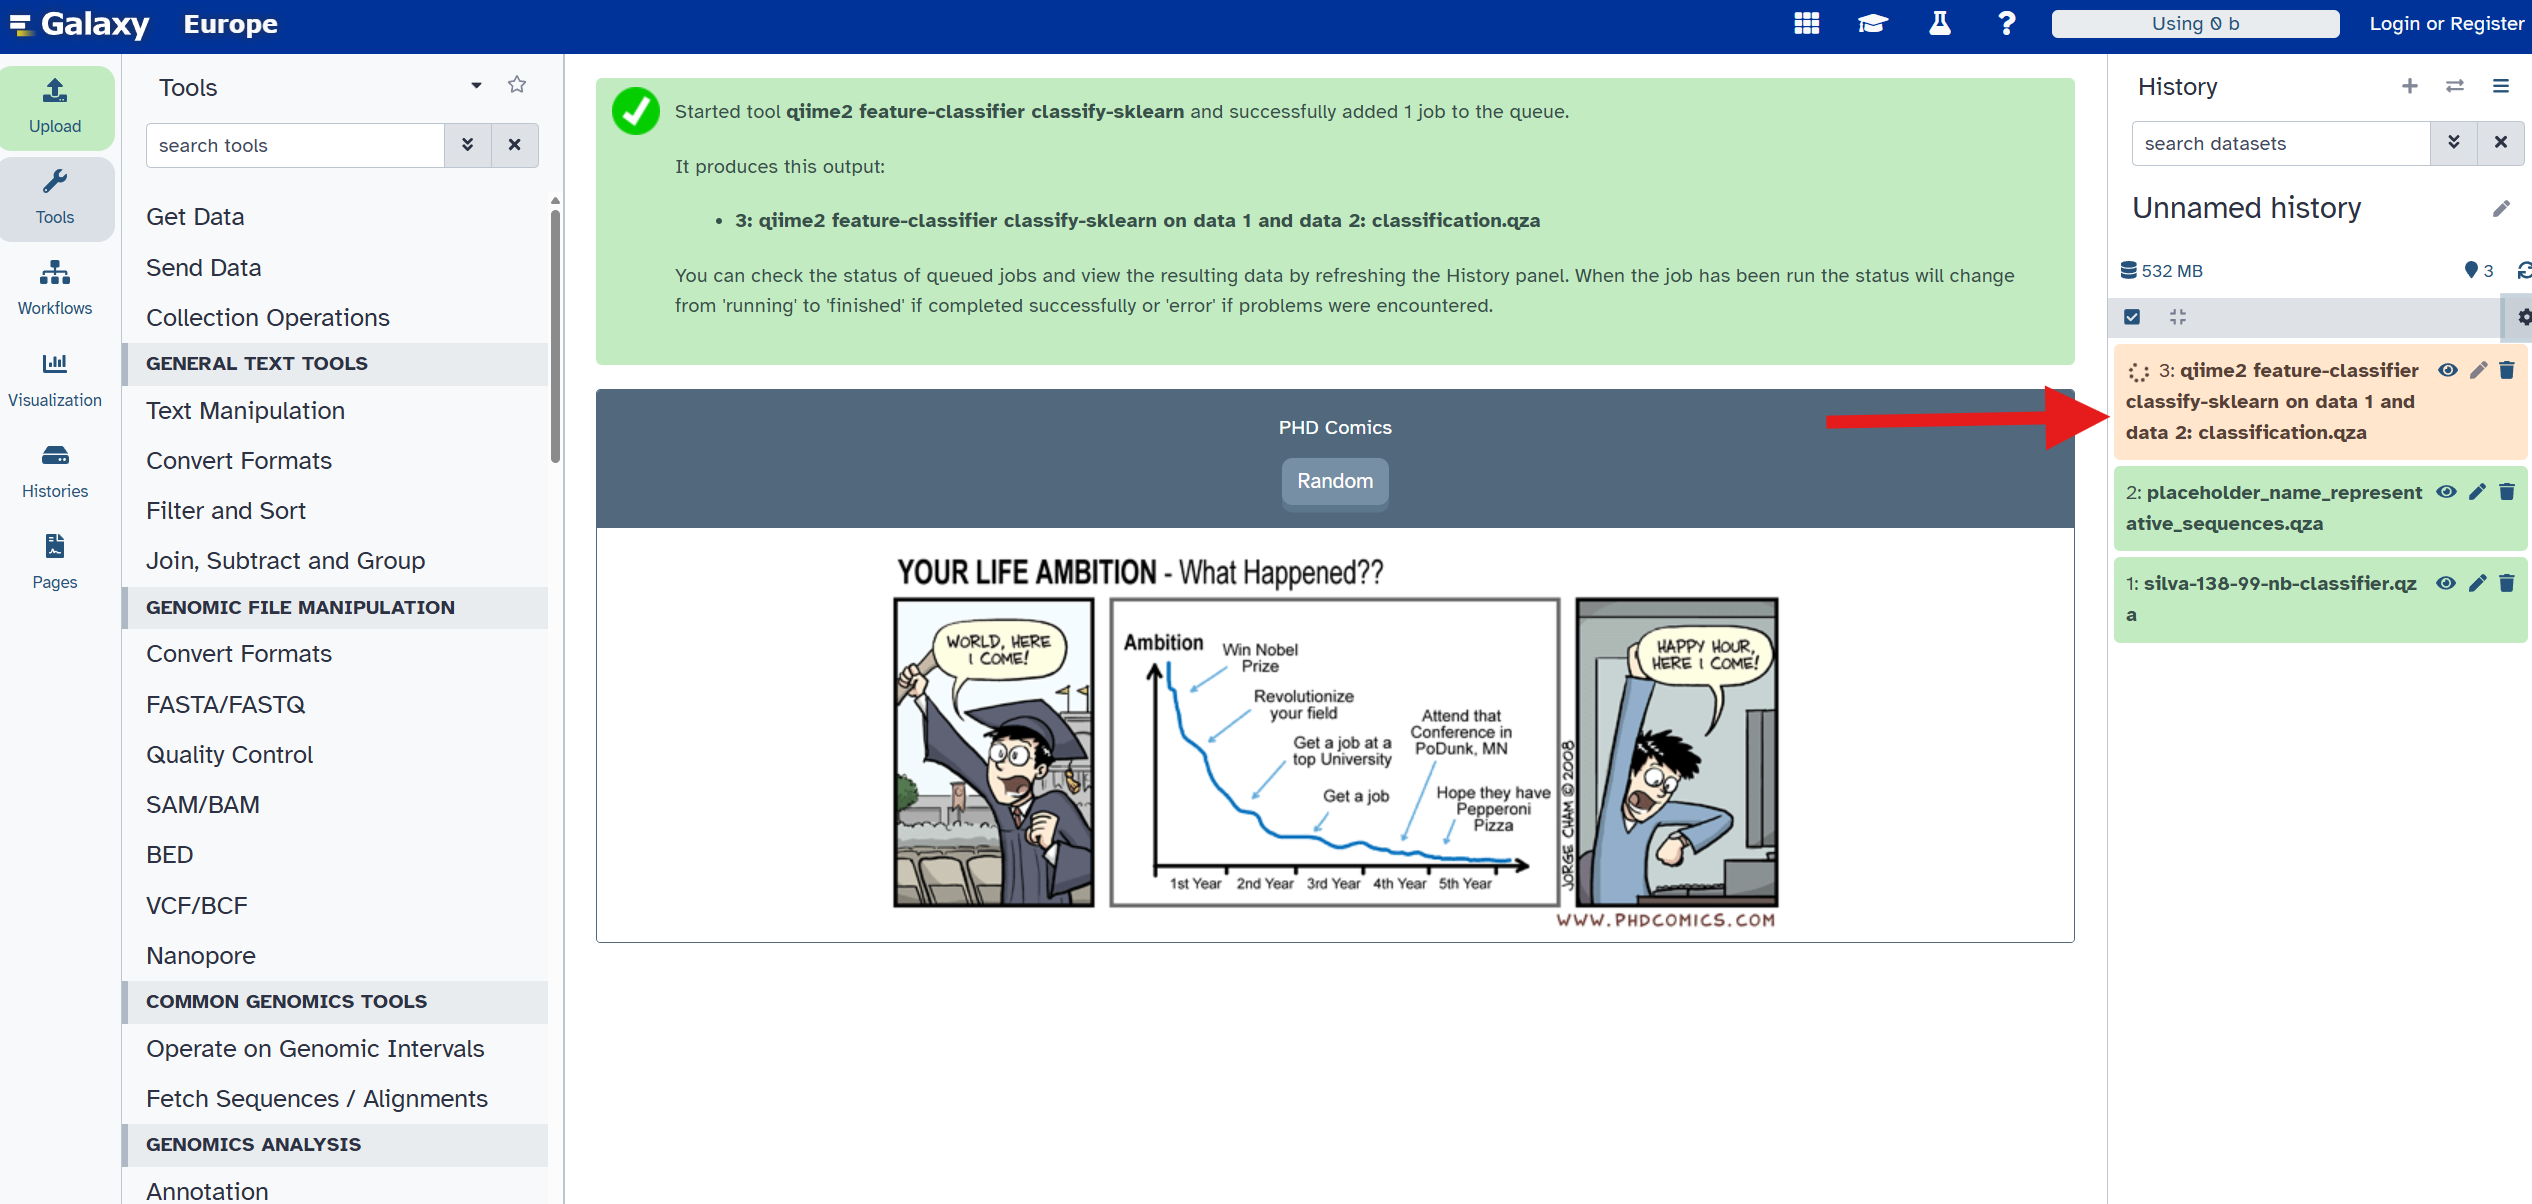

In [ ]:
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step8.png'))

When the taxonomy assignment has successfully finished, you will be able to download it, as pictured below.

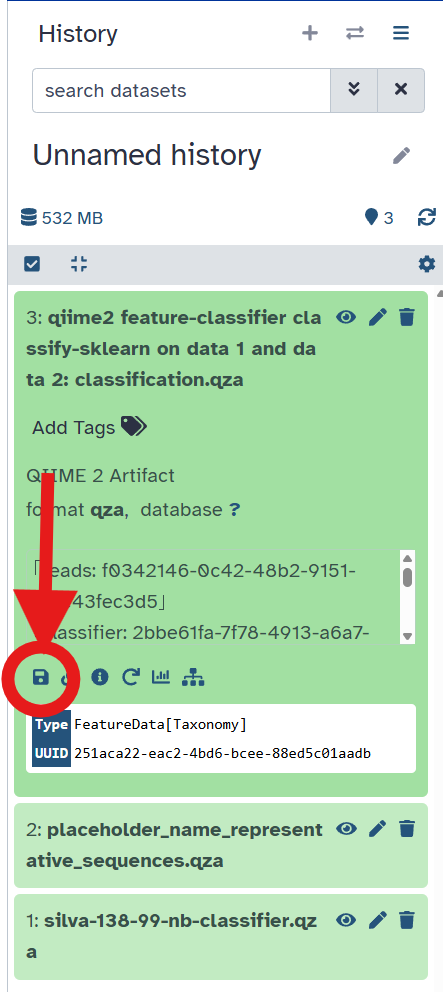

In [ ]:
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step9.png'))

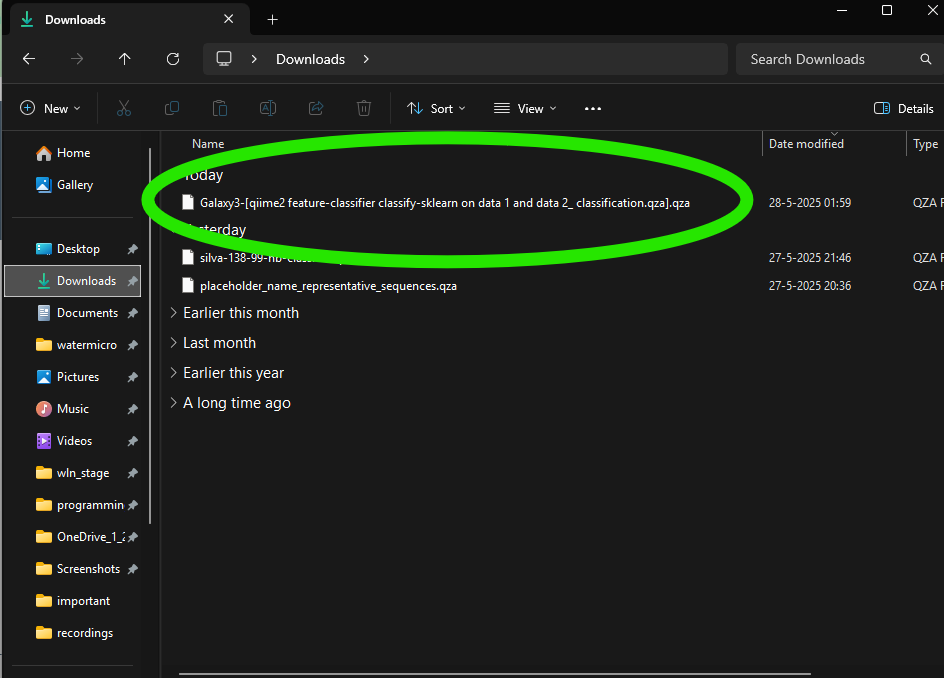

In [ ]:
display(Image(filename='/content/wetsus_repo_analysis/supplementary/step10.png'))

You have now successfully created the required .qza files using QIIME2, and you can proceed with further analysis and creating figures in the next Google Colab part.